In [142]:
import pandas as pd
import numpy as np

# necesitamos importar una librería especifica
from sklearn.impute import KNNImputer
from sklearn.experimental import enable_iterative_imputer

In [143]:
pd.set_option("display.max_columns",None) #display todas las columnas

In [144]:
df_talento = pd.read_csv("files/hr.csv")

In [145]:
df_talento.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41.0,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,sALES eXECUTIVE,4.0,Single,5993.0,19479,8,Y,Yes,11,3,1,80.0,0,8,0.0,1,6,4,0,5.0
1,49.0,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,rESEARCH sCIENTIST,2.0,Married,5130.0,24907,1,Y,No,23,4,4,NaN,1,10,3.0,3,10,7,1,7.0
2,37.0,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,lABORATORY tECHNICIAN,3.0,Single,2090.0,2396,6,Y,Yes,15,3,2,NaN,0,7,3.0,3,0,0,0,0.0
3,33.0,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,rESEARCH sCIENTIST,3.0,Married,2909.0,23159,1,Y,Yes,11,3,3,80.0,0,8,3.0,3,8,7,3,0.0
4,27.0,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,lABORATORY tECHNICIAN,2.0,Married,3468.0,16632,9,Y,No,12,3,4,80.0,1,6,3.0,3,2,2,2,2.0
5,32.0,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,4,Male,79,3,1,lABORATORY tECHNICIAN,4.0,Single,3068.0,11864,0,Y,No,13,3,3,80.0,0,8,2.0,2,7,7,3,6.0
6,59.0,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,3,Female,81,4,1,lABORATORY tECHNICIAN,1.0,Married,2670.0,9964,4,Y,NaN,20,4,1,NaN,3,12,3.0,2,1,0,0,NaN
7,30.0,No,Travel_Rarely,1358,NaN,24,1,Life Sciences,1,11,4,Male,67,3,1,lABORATORY tECHNICIAN,3.0,Divorced,2693.0,13335,1,Y,No,22,4,2,80.0,1,1,2.0,3,1,0,0,0.0
8,38.0,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,4,Male,44,2,3,mANUFACTURING dIRECTOR,3.0,Single,9526.0,8787,0,Y,No,21,4,2,80.0,0,10,2.0,3,9,7,1,8.0
9,36.0,No,Travel_Rarely,1299,Research & Development,27,3,NaN,1,13,3,Male,94,3,2,hEALTHCARE rEPRESENTATIVE,3.0,Married,5237.0,16577,6,Y,No,13,3,2,80.0,2,17,3.0,2,7,7,7,NaN


In [146]:
df_talento.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='str')

In [147]:
pd.Series(df_talento.columns)

0                          Age
1                    Attrition
2               BusinessTravel
3                    DailyRate
4                   Department
5             DistanceFromHome
6                    Education
7               EducationField
8                EmployeeCount
9               EmployeeNumber
10     EnvironmentSatisfaction
11                      Gender
12                  HourlyRate
13              JobInvolvement
14                    JobLevel
15                     JobRole
16             JobSatisfaction
17               MaritalStatus
18               MonthlyIncome
19                 MonthlyRate
20          NumCompaniesWorked
21                      Over18
22                    OverTime
23           PercentSalaryHike
24           PerformanceRating
25    RelationshipSatisfaction
26               StandardHours
27            StockOptionLevel
28           TotalWorkingYears
29       TrainingTimesLastYear
30             WorkLifeBalance
31              YearsAtCompany
32      

In [148]:
df_talento.shape #aqui vemos el número de filas, columnas

(1474, 35)

In [149]:
df_talento.info() #aqui vemos el tipo de datos, los nulos, columnas, etc

<class 'pandas.DataFrame'>
RangeIndex: 1474 entries, 0 to 1473
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       1401 non-null   float64
 1   Attrition                 1474 non-null   str    
 2   BusinessTravel            1357 non-null   str    
 3   DailyRate                 1474 non-null   int64  
 4   Department                1445 non-null   str    
 5   DistanceFromHome          1474 non-null   int64  
 6   Education                 1474 non-null   int64  
 7   EducationField            1416 non-null   str    
 8   EmployeeCount             1474 non-null   int64  
 9   EmployeeNumber            1474 non-null   int64  
 10  EnvironmentSatisfaction   1474 non-null   int64  
 11  Gender                    1474 non-null   str    
 12  HourlyRate                1474 non-null   int64  
 13  JobInvolvement            1474 non-null   int64  
 14  JobLevel           

In [150]:
df_talento.duplicated().sum() #supuestamente hay 4 duplicados.

np.int64(4)

## columnas a modificar tras primera visualización

Age: float a int?

César:

- Attrition - Baja personal o rotación general
- DailyRate - Tarifa diaria, en código, dinero ??
- HourlyRate - Tarifa horaria, código o dinero ?? 
- JobLevel - Nivel de puesto ( jefe - intermedio - "peón")

In [151]:
df_talento[["MonthlyIncome", "MonthlyRate"]].sample(10)

,MonthlyIncome,MonthlyRate
162,2713.0,6672
943,3423.0,22957
1142,5769.0,23447
1383,2810.0,9238
856,3033.0,12828
1087,2308.0,4944
280,17584.0,21016
1385,8628.0,22914
223,10609.0,9647
130,4739.0,16090


# Analizamos si hay cierta coherencia entre el salario, y ratio de salario.

In [152]:
df_talento["ProfitMargen"] = (1 - df_talento["MonthlyIncome"] / df_talento["MonthlyRate"]) * 100

In [153]:
display(round(df_talento[["ProfitMargen", "MonthlyRate", "MonthlyIncome", "JobRole"]]), 2)

,ProfitMargen,MonthlyRate,MonthlyIncome,JobRole
0,69.0,19479,5993.0,sALES eXECUTIVE
1,79.0,24907,5130.0,rESEARCH sCIENTIST
2,13.0,2396,2090.0,lABORATORY tECHNICIAN
3,87.0,23159,2909.0,rESEARCH sCIENTIST
4,79.0,16632,3468.0,lABORATORY tECHNICIAN
...,...,...,...,...
1469,57.0,10228,4404.0,lABORATORY tECHNICIAN
1470,64.0,23490,8463.0,sALES eXECUTIVE
1471,83.0,26250,4450.0,mANUFACTURING dIRECTOR
1472,87.0,11585,1555.0,hUMAN rESOURCES


2

In [286]:
df_talento["DailyRate"].sample(10).reset_index()

,index,DailyRate
0,100,807
1,954,495
2,1013,855
3,438,1276
4,1407,771
5,20,673
6,1049,1358
7,1369,1475
8,189,313
9,1149,1302


In [155]:
round(df_talento.isna().sum()/df_talento.shape[0] * 100), 2

(Age                          5.0
 Attrition                    0.0
 BusinessTravel               8.0
 DailyRate                    0.0
 Department                   2.0
 DistanceFromHome             0.0
 Education                    0.0
 EducationField               4.0
 EmployeeCount                0.0
 EmployeeNumber               0.0
 EnvironmentSatisfaction      0.0
 Gender                       0.0
 HourlyRate                   0.0
 JobInvolvement               0.0
 JobLevel                     0.0
 JobRole                      0.0
 JobSatisfaction              2.0
 MaritalStatus                9.0
 MonthlyIncome                1.0
 MonthlyRate                  0.0
 NumCompaniesWorked           0.0
 Over18                       0.0
 OverTime                     3.0
 PercentSalaryHike            0.0
 PerformanceRating            0.0
 RelationshipSatisfaction     0.0
 StandardHours               11.0
 StockOptionLevel             0.0
 TotalWorkingYears            0.0
 TrainingTimes

In [156]:
df_talento["Over18"].unique()

<StringArray>
['Y']
Length: 1, dtype: str

Comprobamos que la columna "Over18" tiene un valor único, no es representativo

In [157]:
df_talento.sample()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,ProfitMargen
422,19.0,Yes,Travel_Rarely,489,Human Resources,2,2,Technical Degree,1,566,1,Male,52,2,1,hUMAN rESOURCES,4.0,Single,2564.0,18437,1,Y,No,12,3,3,80.0,0,1,3.0,4,1,0,0,0.0,86.093182


In [158]:
df_talento["EmployeeCount"].unique()

array([1])

Comprobamos que la columna "EmployeeCount" tiene un valor único, no es representativo

In [159]:
df_talento["JobSatisfaction"].isna().sum()

np.int64(29)

In [160]:
df_talento["Age"].isna().sum()

np.int64(73)

In [161]:
df_talento["Age"].dtype

dtype('float64')

In [162]:
display(df_talento.describe(include="str").T)

,count,unique,top,freq
Attrition,1474,2,No,1236
BusinessTravel,1357,3,Travel_Rarely,955
Department,1445,3,Research & Development,941
EducationField,1416,6,Life Sciences,582
Gender,1474,2,Male,885
JobRole,1474,9,sALES eXECUTIVE,327
MaritalStatus,1342,4,Married,604
Over18,1474,1,Y,1474
OverTime,1430,2,No,1025


Interpretaciones:

- Attrition: De los 1474 registros, 1236 son "No". Esto indica un fuerte desbalanceo (solo un ~16% de los empleados se han ido). Al entrenar modelos más adelante, tendrás que tener esto en cuenta para que no ignore los casos de "Yes".

In [163]:
display(round(df_talento.describe(exclude=str).T), 2)

,count,mean,std,min,25%,50%,75%,max
Age,1401.0,37.0,9.0,18.0,30.0,36.0,43.0,60.0
DailyRate,1474.0,803.0,404.0,102.0,465.0,803.0,1157.0,1499.0
DistanceFromHome,1474.0,9.0,8.0,1.0,2.0,7.0,14.0,29.0
Education,1474.0,3.0,1.0,1.0,2.0,3.0,4.0,5.0
EmployeeCount,1474.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0
EmployeeNumber,1474.0,1024.0,602.0,1.0,489.0,1020.0,1556.0,2068.0
EnvironmentSatisfaction,1474.0,3.0,1.0,1.0,2.0,3.0,4.0,4.0
HourlyRate,1474.0,66.0,20.0,30.0,48.0,66.0,84.0,100.0
JobInvolvement,1474.0,3.0,1.0,1.0,2.0,3.0,3.0,4.0
JobLevel,1474.0,2.0,1.0,1.0,1.0,2.0,3.0,5.0


2

In [164]:
df_talento["JobRole"] = df_talento["JobRole"].str.lower()

In [165]:
df_talento["JobRole"]

0               sales executive 
1            research scientist 
2         laboratory technician 
3            research scientist 
4         laboratory technician 
                  ...           
1469      laboratory technician 
1470            sales executive 
1471     manufacturing director 
1472            human resources 
1473         research scientist 
Name: JobRole, Length: 1474, dtype: str

In [166]:
df_talento.duplicated().sum()

np.int64(4)

In [167]:
df_talento["JobRole"].str.strip().str.capitalize()

0              Sales executive
1           Research scientist
2        Laboratory technician
3           Research scientist
4        Laboratory technician
                 ...          
1469     Laboratory technician
1470           Sales executive
1471    Manufacturing director
1472           Human resources
1473        Research scientist
Name: JobRole, Length: 1474, dtype: str

Funcion para sacar datos de los dataframes y las columnas

In [168]:
def info_df(dataframe, search=None, sample_n=5):
    print("Informacion sobre el dataframe:")
    dataframe.info()
    print("-" * 100)

    print("La descripcion del dataframe de strings:")
    display(dataframe.describe(include=[object, "category"]).T)
    print("-" * 100)

    print("La descripcion del dataframe numerico:")
    display(dataframe.describe(exclude=[object, "category"]).T)
    print("-" * 100)

    print(f"La forma del dataframe es:\n{dataframe.shape[0]} filas\n{dataframe.shape[1]} columnas")
    print("-" * 100)

    if search:
        search_str = str(search).strip().lower()
        cols_match = [c for c in dataframe.columns if search_str in c.lower()]
        print(f"Columnas que contienen '{search}': {cols_match if cols_match else 'ninguna'}")

        mask = dataframe.apply(lambda col: col.astype(str).str.contains(search_str, case=False, na=False))
        rows_match = dataframe[mask.any(axis=1)]
        print(f"Filas con '{search}': {rows_match.shape[0]} encontrada(s)")
        if not rows_match.empty:
            display(rows_match.head(sample_n))
        else:
            print("No se encontraron filas con ese criterio.")
        print("-" * 100)

    print("Muestra del dataframe:")
    display(dataframe.sample(min(sample_n, len(dataframe))))


In [169]:
info_df(df_talento)

Informacion sobre el dataframe:
<class 'pandas.DataFrame'>
RangeIndex: 1474 entries, 0 to 1473
Data columns (total 36 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       1401 non-null   float64
 1   Attrition                 1474 non-null   str    
 2   BusinessTravel            1357 non-null   str    
 3   DailyRate                 1474 non-null   int64  
 4   Department                1445 non-null   str    
 5   DistanceFromHome          1474 non-null   int64  
 6   Education                 1474 non-null   int64  
 7   EducationField            1416 non-null   str    
 8   EmployeeCount             1474 non-null   int64  
 9   EmployeeNumber            1474 non-null   int64  
 10  EnvironmentSatisfaction   1474 non-null   int64  
 11  Gender                    1474 non-null   str    
 12  HourlyRate                1474 non-null   int64  
 13  JobInvolvement            1474 non-null   

C:\Users\xiky_\AppData\Local\Temp\ipykernel_42884\376643467.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(dataframe.describe(include=[object, "category"]).T)


,count,unique,top,freq
Attrition,1474,2,No,1236
BusinessTravel,1357,3,Travel_Rarely,955
Department,1445,3,Research & Development,941
EducationField,1416,6,Life Sciences,582
Gender,1474,2,Male,885
JobRole,1474,9,sales executive,327
MaritalStatus,1342,4,Married,604
Over18,1474,1,Y,1474
OverTime,1430,2,No,1025


----------------------------------------------------------------------------------------------------
La descripcion del dataframe numerico:


,count,mean,std,min,25%,50%,75%,max
Age,1401.0,36.944325,9.105009,18.000000,30.000000,36.000000,43.000000,60.000000
DailyRate,1474.0,802.702171,403.539530,102.000000,465.000000,803.000000,1157.000000,1499.000000
DistanceFromHome,1474.0,9.199457,8.104266,1.000000,2.000000,7.000000,14.000000,29.000000
Education,1474.0,2.911126,1.024267,1.000000,2.000000,3.000000,4.000000,5.000000
EmployeeCount,1474.0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
EmployeeNumber,1474.0,1024.471506,602.421193,1.000000,488.750000,1020.500000,1555.750000,2068.000000
EnvironmentSatisfaction,1474.0,2.723881,1.093280,1.000000,2.000000,3.000000,4.000000,4.000000
HourlyRate,1474.0,65.887381,20.310444,30.000000,48.000000,66.000000,83.750000,100.000000
JobInvolvement,1474.0,2.729986,0.712861,1.000000,2.000000,3.000000,3.000000,4.000000
JobLevel,1474.0,2.063772,1.106055,1.000000,1.000000,2.000000,3.000000,5.000000


----------------------------------------------------------------------------------------------------
La forma del dataframe es:
1474 filas
36 columnas
----------------------------------------------------------------------------------------------------
Muestra del dataframe:


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,ProfitMargen
1288,35.0,No,NaN,1180,Research & Development,2,2,Medical,1,1804,2,Male,90,3,2,manufacturing director,4.0,Divorced,5762.0,24442,2,Y,No,14,3,3,80.0,1,15,6.0,3,7,7,1,7.0,76.425824
482,31.0,Yes,NaN,1365,Sales,13,4,Medical,1,650,2,Male,46,3,2,sales executive,1.0,Divorced,4233.0,11512,2,Y,No,17,3,3,80.0,0,9,2.0,1,3,1,1,2.0,63.229673
724,24.0,No,Travel_Rarely,1206,Research & Development,17,1,Medical,1,1009,4,Female,41,2,2,manufacturing director,3.0,Divorced,4377.0,24117,1,Y,No,15,3,2,80.0,2,5,6.0,3,4,2,3,2.0,81.850976
119,43.0,No,Travel_Frequently,394,Sales,26,2,Life Sciences,1,158,3,Male,92,3,4,manager,4.0,NaN,16959.0,19494,1,Y,Yes,12,3,4,80.0,2,25,3.0,4,25,12,4,12.0,13.004001
4,27.0,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,laboratory technician,2.0,Married,3468.0,16632,9,Y,No,12,3,4,80.0,1,6,3.0,3,2,2,2,2.0,79.148629


In [170]:
def analisis_columnas (dataframe):
    for columna in dataframe:
        print(f"Columna: {columna}\n {"-" * 100}")
        print(f"Valores unicos: {dataframe[columna].unique()}\n {"-" * 100}")
        print(f"Valores duplicados: {dataframe[columna].duplicated().sum()}\n {"-" * 100}")
        print(f"Valores nulos: {dataframe[columna].isna().sum()}\n {"-" * 100}")
        print(f"El tipo de dato: {dataframe[columna].dtype}\n {"-" * 100}")


In [171]:
analisis_columnas(df_talento)

Columna: Age
 ----------------------------------------------------------------------------------------------------
Valores unicos: [41. 49. 37. 33. 27. 32. 59. 30. 38. 36. 35. 29. 31. 34. 28. 22. 53. 24.
 21. 42. 44. 46. 39. 43. 50. 26. 48. nan 55. 45. 56. 23. 51. 40. 54. 58.
 20. 25. 19. 57. 52. 47. 18. 60.]
 ----------------------------------------------------------------------------------------------------
Valores duplicados: 1430
 ----------------------------------------------------------------------------------------------------
Valores nulos: 73
 ----------------------------------------------------------------------------------------------------
El tipo de dato: float64
 ----------------------------------------------------------------------------------------------------
Columna: Attrition
 ----------------------------------------------------------------------------------------------------
Valores unicos: <StringArray>
['Yes', 'No']
Length: 2, dtype: str
 -------------------------

In [172]:
df_talento.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager', 'ProfitMargen'],
      dtype='str')

In [173]:
display(round(df_talento[['DailyRate', 'HourlyRate', 'MonthlyIncome', 'MonthlyRate']].describe().T), 2)

,count,mean,std,min,25%,50%,75%,max
DailyRate,1474.0,803.0,404.0,102.0,465.0,803.0,1157.0,1499.0
HourlyRate,1474.0,66.0,20.0,30.0,48.0,66.0,84.0,100.0
MonthlyIncome,1460.0,6497.0,4706.0,1009.0,2909.0,4907.0,8377.0,19999.0
MonthlyRate,1474.0,14329.0,7120.0,2094.0,8054.0,14248.0,20466.0,26999.0


2

In [174]:
df_talento[['DailyRate', 'HourlyRate', 'MonthlyIncome', 'MonthlyRate', 'JobRole']].sample(2)

,DailyRate,HourlyRate,MonthlyIncome,MonthlyRate,JobRole
642,395,98,2899.0,12102,sales representative
892,504,96,1859.0,6148,research scientist


In [175]:
df_talento.groupby("JobLevel")[['DailyRate', 'HourlyRate', 'MonthlyIncome', 'MonthlyRate']].mean()

,DailyRate,HourlyRate,MonthlyIncome,MonthlyRate
JobLevel,,,,
1,802.812500,66.740809,2784.527778,13682.580882
2,794.529851,65.787313,5499.277358,14812.188433
3,832.086758,64.164384,9816.212963,14653.420091
4,774.452830,65.679245,15503.783019,14538.547170
5,815.449275,65.724638,19181.029412,14312.057971


In [176]:
df_limpio = df_talento.drop(columns=["DailyRate", "HourlyRate",	"MonthlyRate", "EmployeeCount", "Over18"])

In [177]:
df_limpio.drop(columns=['ProfitMargen'], inplace=True)

In [178]:
df_limpio.shape

(1474, 30)

In [179]:
df_limpio.sample()

,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,Gender,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
160,22.0,No,Travel_Rarely,Research & Development,19,1,Medical,217,3,Male,3,1,research scientist,4.0,Married,2323.0,1,No,24,4,1,80.0,2,2,6.0,3,2,2,2,2.0


In [180]:
analisis_columnas(df_limpio)

Columna: Age
 ----------------------------------------------------------------------------------------------------
Valores unicos: [41. 49. 37. 33. 27. 32. 59. 30. 38. 36. 35. 29. 31. 34. 28. 22. 53. 24.
 21. 42. 44. 46. 39. 43. 50. 26. 48. nan 55. 45. 56. 23. 51. 40. 54. 58.
 20. 25. 19. 57. 52. 47. 18. 60.]
 ----------------------------------------------------------------------------------------------------
Valores duplicados: 1430
 ----------------------------------------------------------------------------------------------------
Valores nulos: 73
 ----------------------------------------------------------------------------------------------------
El tipo de dato: float64
 ----------------------------------------------------------------------------------------------------
Columna: Attrition
 ----------------------------------------------------------------------------------------------------
Valores unicos: <StringArray>
['Yes', 'No']
Length: 2, dtype: str
 -------------------------

In [181]:
df_limpio.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
1469    False
1470     True
1471     True
1472     True
1473     True
Length: 1474, dtype: bool

In [182]:
#df_limpio.drop_duplicates(inplace=True)

In [183]:
duplicados = df_limpio[df_limpio.duplicated()]
print(duplicados.index)

RangeIndex(start=1470, stop=1474, step=1)


In [184]:
df_limpio.iloc[1470:1475:1]

,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,Gender,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1470,28.0,No,Travel_Rarely,Sales,5,3,Medical,1469,4,Male,3,2,sales executive,1.0,Single,8463.0,0,No,18,3,4,NaN,0,6,4.0,3,5,4,1,NaN
1471,53.0,No,Travel_Rarely,Research & Development,13,2,Medical,250,4,Female,4,2,manufacturing director,1.0,Divorced,4450.0,1,No,11,3,3,NaN,2,5,3.0,3,4,2,1,3.0
1472,24.0,Yes,Travel_Rarely,Human Resources,22,1,Human Resources,1714,4,Male,1,1,human resources,3.0,Married,1555.0,1,No,11,3,3,80.0,1,1,2.0,3,1,0,0,0.0
1473,45.0,No,Travel_Rarely,Research & Development,7,3,Life Sciences,86,2,Male,3,3,research scientist,1.0,Divorced,9724.0,2,No,17,3,3,NaN,1,25,2.0,3,1,0,0,0.0


In [185]:
duplicadas = df_limpio.loc[df_limpio.duplicated()]
print(duplicadas)

       Age Attrition BusinessTravel              Department  DistanceFromHome  \
1470  28.0        No  Travel_Rarely                   Sales                 5   
1471  53.0        No  Travel_Rarely  Research & Development                13   
1472  24.0       Yes  Travel_Rarely         Human Resources                22   
1473  45.0        No  Travel_Rarely  Research & Development                 7   

      Education   EducationField  EmployeeNumber  EnvironmentSatisfaction  \
1470          3          Medical            1469                        4   
1471          2          Medical             250                        4   
1472          1  Human Resources            1714                        4   
1473          3    Life Sciences              86                        2   

      Gender  JobInvolvement  JobLevel                   JobRole  \
1470    Male               3         2          sales executive    
1471  Female               4         2   manufacturing director    
1472

In [186]:
df_limpio.tail()

,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,Gender,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1469,34.0,No,Travel_Rarely,Research & Development,8,3,Medical,2068,2,Male,4,2,laboratory technician,3.0,Married,4404.0,2,No,12,3,1,NaN,0,6,3.0,4,4,3,1,2.0
1470,28.0,No,Travel_Rarely,Sales,5,3,Medical,1469,4,Male,3,2,sales executive,1.0,Single,8463.0,0,No,18,3,4,NaN,0,6,4.0,3,5,4,1,NaN
1471,53.0,No,Travel_Rarely,Research & Development,13,2,Medical,250,4,Female,4,2,manufacturing director,1.0,Divorced,4450.0,1,No,11,3,3,NaN,2,5,3.0,3,4,2,1,3.0
1472,24.0,Yes,Travel_Rarely,Human Resources,22,1,Human Resources,1714,4,Male,1,1,human resources,3.0,Married,1555.0,1,No,11,3,3,80.0,1,1,2.0,3,1,0,0,0.0
1473,45.0,No,Travel_Rarely,Research & Development,7,3,Life Sciences,86,2,Male,3,3,research scientist,1.0,Divorced,9724.0,2,No,17,3,3,NaN,1,25,2.0,3,1,0,0,0.0


In [187]:
df_limpio.columns 
# **DailyRate** **HourlyRate** **MonthlyRate**
# **EmployeeCount**, **Over18*

Index(['Age', 'Attrition', 'BusinessTravel', 'Department', 'DistanceFromHome',
       'Education', 'EducationField', 'EmployeeNumber',
       'EnvironmentSatisfaction', 'Gender', 'JobInvolvement', 'JobLevel',
       'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome',
       'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='str')

In [188]:
df_limpio["MaritalStatus"].unique()

<StringArray>
['Single', 'Married', 'Divorced', nan, 'Marreid']
Length: 5, dtype: str

In [189]:
#vamos a cambiar el marreid por Married
df_limpio[df_limpio["MaritalStatus"] == "Marreid"] #solo hay 3 mal escritos


df_limpio['MaritalStatus'] = df_limpio['MaritalStatus'].str.replace('Marreid', 'Married')


In [190]:
df_limpio["MaritalStatus"].unique() #ya lo tenemos cambiado y bien

<StringArray>
['Single', 'Married', 'Divorced', nan]
Length: 4, dtype: str

In [191]:
df_limpio = df_limpio.apply(lambda x: x.str.lower() if x.dtype == "str" else x) #para cambiar los nombres de las variables a minusculas

In [192]:
df_limpio.head()

,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,Gender,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41.0,yes,travel_rarely,sales,1,2,life sciences,1,2,female,3,2,sales executive,4.0,single,5993.0,8,yes,11,3,1,80.0,0,8,0.0,1,6,4,0,5.0
1,49.0,no,travel_frequently,research & development,8,1,life sciences,2,3,male,2,2,research scientist,2.0,married,5130.0,1,no,23,4,4,NaN,1,10,3.0,3,10,7,1,7.0
2,37.0,yes,travel_rarely,research & development,2,2,other,4,4,male,2,1,laboratory technician,3.0,single,2090.0,6,yes,15,3,2,NaN,0,7,3.0,3,0,0,0,0.0
3,33.0,no,travel_frequently,research & development,3,4,life sciences,5,4,female,3,1,research scientist,3.0,married,2909.0,1,yes,11,3,3,80.0,0,8,3.0,3,8,7,3,0.0
4,27.0,no,travel_rarely,research & development,2,1,medical,7,1,male,3,1,laboratory technician,2.0,married,3468.0,9,no,12,3,4,80.0,1,6,3.0,3,2,2,2,2.0


In [193]:
df_limpio.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'Department', 'DistanceFromHome',
       'Education', 'EducationField', 'EmployeeNumber',
       'EnvironmentSatisfaction', 'Gender', 'JobInvolvement', 'JobLevel',
       'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome',
       'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='str')

In [194]:
#lista y bucle con las columnas de rate que deberian ser del 1 al 4
lista = ["EnvironmentSatisfaction", "JobInvolvement", "JobSatisfaction", "PerformanceRating", "RelationshipSatisfaction" ]

In [195]:
for a in lista:
    print(a, df_limpio[a].unique())
    

EnvironmentSatisfaction [2 3 4 1]
JobInvolvement [3 2 4 1]
JobSatisfaction [ 4.  2.  3.  1. nan]
PerformanceRating [3 4]
RelationshipSatisfaction [1 4 2 3]


In [196]:
round(df_limpio.isnull().sum()/df_limpio.shape[0]*100, 2).sort_values(ascending = False).head(15)
#nuestros valores nulos en porcentajes y lo que suponen del df

StandardHours            11.13
YearsWithCurrManager     10.04
MaritalStatus             8.96
BusinessTravel            7.94
TrainingTimesLastYear     5.97
Age                       4.95
EducationField            3.93
OverTime                  2.99
JobSatisfaction           1.97
Department                1.97
MonthlyIncome             0.95
DistanceFromHome          0.00
Education                 0.00
Attrition                 0.00
JobRole                   0.00
dtype: float64

In [197]:
df_limpio["StandardHours"].unique()

array([80., nan])

In [198]:
#vamos a cargarnos el StandarHours
df_limpio = df_limpio.drop('StandardHours', axis=1)

In [199]:
df_limpio.head(2)

,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,Gender,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41.0,yes,travel_rarely,sales,1,2,life sciences,1,2,female,3,2,sales executive,4.0,single,5993.0,8,yes,11,3,1,0,8,0.0,1,6,4,0,5.0
1,49.0,no,travel_frequently,research & development,8,1,life sciences,2,3,male,2,2,research scientist,2.0,married,5130.0,1,no,23,4,4,1,10,3.0,3,10,7,1,7.0


Age                          5.0
 BusinessTravel               8.0
 Department                   2.0
 EducationField               4.0
 JobSatisfaction              2.0
 MaritalStatus                9.0
 MonthlyIncome                1.0
 OverTime                     3.0
 YearsWithCurrManager        10.0
 ProfitMargen                 1.0
 Age                          73
BusinessTravel              117
Department                   29
EducationField               58
JobSatisfaction              29
MaritalStatus               132
MonthlyIncome                14
OverTime                     44
TrainingTimesLastYear        88
YearsWithCurrManager        148
ProfitMargen                 14

In [200]:
df_limpio["YearsWithCurrManager"].unique()

array([ 5.,  7.,  0.,  2.,  6., nan,  8.,  3., 11., 17.,  4.,  1., 12.,
        9., 10., 15., 13., 16., 14.])

In [201]:
df_limpio["YearsWithCurrManager"].describe()

count    1326.000000
mean        4.061840
std         3.517603
min         0.000000
25%         2.000000
50%         3.000000
75%         7.000000
max        17.000000
Name: YearsWithCurrManager, dtype: float64

In [202]:
#como vamos a reemplazar por la media o por la mediana?
#ANTE LA DUDA = mediana

round(df_limpio.groupby("YearsWithCurrManager")[["YearsAtCompany"]].mean(), 2)


,YearsAtCompany
YearsWithCurrManager,
0.0,2.12
1.0,5.00
2.0,3.57
3.0,5.20
4.0,6.01
5.0,8.48
6.0,11.81
7.0,9.89
8.0,12.41


In [203]:
round(df_limpio.groupby("YearsAtCompany")[["YearsWithCurrManager"]].agg(["mean", "median"]), 2)


YearsWithCurrManager       
                               mean median
YearsAtCompany                            
0                              0.00    0.0
1                              0.07    0.0
2                              1.75    2.0
3                              1.87    2.0
4                              2.25    2.0
5                              2.84    3.0
6                              2.97    3.0
7                              5.93    7.0
8                              5.78    7.0
9                              5.85    7.0
10                             6.63    7.0
11                             7.44    8.0
12                             8.23    8.0
13                             8.04    8.0
14                             8.94    9.0
15                            10.26   11.0
16                             9.64   10.0
17                             9.89    9.0
18                            11.18   11.0
19                             7.90    8.0
20                            10.24    9.0
21                             8.62    8.0
22                             9.62   10.0
23                             4.00    4.0
24                            10.00   10.0
25                             9.50    9.5
26                             6.33    7.0
27                             7.50    7.5
29                            10.00   10.0
30                            13.00   13.0
31                             8.00    8.0
32                             8.33    9.0
33                             7.00    9.0
34                            16.00   16.0
36                            13.00   13.0
37                             8.00    8.0
40                             6.00    6.0

In [204]:
import re

#funcion patron regex para transformar los nombres de las columnas a snake_case
def transformar_nombre(nombre):
    # Agrega un guion bajo antes de cada mayúscula y lo pasa a minúsculas
    # El '(?<=[a-z])' busca una mayúscula que tenga una minúscula detrás
    nuevo_nombre = re.sub(r'(?<!^)(?=[A-Z])', '_', nombre).lower()
    return nuevo_nombre

# Aplicamos la función a todas las columnas usando una lista de comprensión
df_limpio.columns = [transformar_nombre(col) for col in df_limpio.columns]


df_limpio.head()    

,age,attrition,business_travel,department,distance_from_home,education,education_field,employee_number,environment_satisfaction,gender,job_involvement,job_level,job_role,job_satisfaction,marital_status,monthly_income,num_companies_worked,over_time,percent_salary_hike,performance_rating,relationship_satisfaction,stock_option_level,total_working_years,training_times_last_year,work_life_balance,years_at_company,years_in_current_role,years_since_last_promotion,years_with_curr_manager
0,41.0,yes,travel_rarely,sales,1,2,life sciences,1,2,female,3,2,sales executive,4.0,single,5993.0,8,yes,11,3,1,0,8,0.0,1,6,4,0,5.0
1,49.0,no,travel_frequently,research & development,8,1,life sciences,2,3,male,2,2,research scientist,2.0,married,5130.0,1,no,23,4,4,1,10,3.0,3,10,7,1,7.0
2,37.0,yes,travel_rarely,research & development,2,2,other,4,4,male,2,1,laboratory technician,3.0,single,2090.0,6,yes,15,3,2,0,7,3.0,3,0,0,0,0.0
3,33.0,no,travel_frequently,research & development,3,4,life sciences,5,4,female,3,1,research scientist,3.0,married,2909.0,1,yes,11,3,3,0,8,3.0,3,8,7,3,0.0
4,27.0,no,travel_rarely,research & development,2,1,medical,7,1,male,3,1,laboratory technician,2.0,married,3468.0,9,no,12,3,4,1,6,3.0,3,2,2,2,2.0


In [205]:
media=df_limpio["years_with_curr_manager"].mean()
print(media)

4.06184012066365


In [206]:
df_limpio["media_year"]=df_limpio["years_with_curr_manager"].fillna(media)

In [207]:
df_limpio.head()

,age,attrition,business_travel,department,distance_from_home,education,education_field,employee_number,environment_satisfaction,gender,job_involvement,job_level,job_role,job_satisfaction,marital_status,monthly_income,num_companies_worked,over_time,percent_salary_hike,performance_rating,relationship_satisfaction,stock_option_level,total_working_years,training_times_last_year,work_life_balance,years_at_company,years_in_current_role,years_since_last_promotion,years_with_curr_manager,media_year
0,41.0,yes,travel_rarely,sales,1,2,life sciences,1,2,female,3,2,sales executive,4.0,single,5993.0,8,yes,11,3,1,0,8,0.0,1,6,4,0,5.0,5.0
1,49.0,no,travel_frequently,research & development,8,1,life sciences,2,3,male,2,2,research scientist,2.0,married,5130.0,1,no,23,4,4,1,10,3.0,3,10,7,1,7.0,7.0
2,37.0,yes,travel_rarely,research & development,2,2,other,4,4,male,2,1,laboratory technician,3.0,single,2090.0,6,yes,15,3,2,0,7,3.0,3,0,0,0,0.0,0.0
3,33.0,no,travel_frequently,research & development,3,4,life sciences,5,4,female,3,1,research scientist,3.0,married,2909.0,1,yes,11,3,3,0,8,3.0,3,8,7,3,0.0,0.0
4,27.0,no,travel_rarely,research & development,2,1,medical,7,1,male,3,1,laboratory technician,2.0,married,3468.0,9,no,12,3,4,1,6,3.0,3,2,2,2,2.0,2.0


In [208]:
df_limpio["mediana_year"]=df_limpio["years_with_curr_manager"].fillna(df_limpio["years_with_curr_manager"].median())

In [209]:
df_limpio.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1401.0,36.944325,9.105009,18.0,30.00,36.0,43.00,60.0
distance_from_home,1474.0,9.199457,8.104266,1.0,2.00,7.0,14.00,29.0
education,1474.0,2.911126,1.024267,1.0,2.00,3.0,4.00,5.0
employee_number,1474.0,1024.471506,602.421193,1.0,488.75,1020.5,1555.75,2068.0
environment_satisfaction,1474.0,2.723881,1.093280,1.0,2.00,3.0,4.00,4.0
job_involvement,1474.0,2.729986,0.712861,1.0,2.00,3.0,3.00,4.0
job_level,1474.0,2.063772,1.106055,1.0,1.00,2.0,3.00,5.0
job_satisfaction,1445.0,2.728720,1.106409,1.0,2.00,3.0,4.00,4.0
monthly_income,1460.0,6497.448630,4706.059294,1009.0,2909.00,4907.0,8377.00,19999.0
num_companies_worked,1474.0,2.688602,2.496443,0.0,1.00,2.0,4.00,9.0


In [210]:
df_limpio.shape #Vemos que efectivamente se han rellenado los nulos.
# hemos concluido que nos quedamos con la mediana ya que no vemos cambios significativos y no tiene valores decimales(más apropiado para los años)


(1474, 31)

| Age                          | 5.0 | 
|  BusinessTravel              | 8.0 | 
|  Department                  | 2.0 | 
|  EducationField              | 4.0 | 
|  JobSatisfaction             | 2.0 |
|  MaritalStatus               | 9.0 |
|  MonthlyIncome               | 1.0 |
|  OverTime                    | 3.0 |
|  YearsWithCurrManager        | 10.0

| Age                         |  73 | 
| BusinessTravel              | 117 | 
| Department                  | 29  | 
| EducationField              | 58  | 
| JobSatisfaction             | 29  | 
| MaritalStatus               | 132 | 
| MonthlyIncome               | 14  | 
| OverTime                    | 44  | 
| TrainingTimesLastYear       | 88  | 
| YearsWithCurrManager        | 148 

In [211]:
df_limpio[["marital_status"]].describe().T

,count,unique,top,freq
marital_status,1342,3,married,607


In [212]:
df_limpio["marital_status"].value_counts(dropna=False).reset_index()

,marital_status,count
0,married,607
1,single,437
2,divorced,298
3,NaN,132


In [213]:
round(df_limpio["marital_status"].value_counts(dropna=False)/(df_limpio.shape[0])*100,2).reset_index()

,marital_status,count
0,married,41.18
1,single,29.65
2,divorced,20.22
3,NaN,8.96


In [214]:
# primero nuestras librerias!

# Tratamiento de datos
# -----------------------------------------------------------------------
import pandas as pd

# Visualización
# ------------------------------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración
# -----------------------------------------------------------------------
pd.set_option('display.max_columns', None) # para poder visualizar todas las columnas de los DataFrames

In [215]:
import warnings # Para controlar las advertencias
warnings.filterwarnings('ignore', category=FutureWarning) # Para ignorar las advertencias de tipo FutureWarning

In [216]:
#Categorizarlo como desconocido y comprobar si encaja con el patron de : married, single o divorced. 
# Asi podremos justificar esa decisión de porque lo hemos metido en ello.

In [217]:
df_limpio["marital_status"]=df_limpio["marital_status"].fillna("unknown")


In [218]:
round(df_limpio["marital_status"].value_counts(dropna=False)/(df_limpio.shape[0])*100,2).reset_index()

,marital_status,count
0,married,41.18
1,single,29.65
2,divorced,20.22
3,unknown,8.96


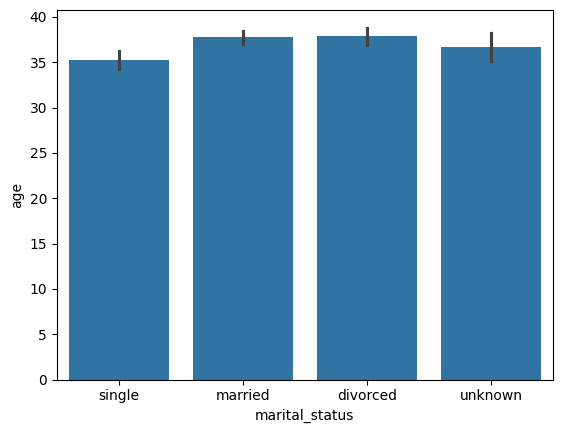

In [219]:
sns.barplot(data=df_limpio,x="marital_status",y="age");

In [220]:
#no hemos encontrado ningún patron claro en cuanto al grupo que puede pertenecer el uknown por lo tanto lo dejamos asi

<Axes: xlabel='marital_status', ylabel='count'>

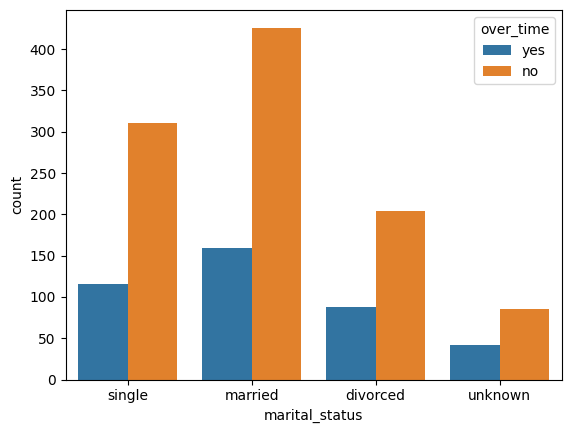

In [221]:
sns.countplot(data=df_limpio,x="marital_status",hue="over_time")

<Axes: xlabel='marital_status', ylabel='count'>

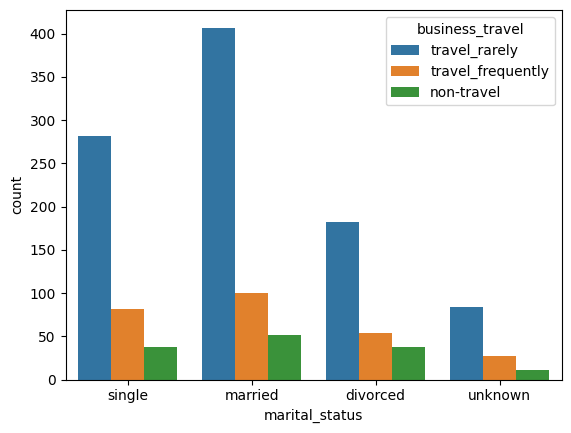

In [222]:
sns.countplot(data=df_limpio,x="marital_status",hue="business_travel")

In [223]:
df_limpio["business_travel"].value_counts(dropna=False)/df_limpio.shape[0]*100


business_travel
travel_rarely        64.789688
travel_frequently    17.842605
non-travel            9.430122
NaN                   7.937585
Name: count, dtype: float64

In [224]:
df_limpio["business_travel"]= df_limpio["business_travel"].fillna("unknown")
df_limpio["business_travel"].value_counts()

business_travel
travel_rarely        955
travel_frequently    263
non-travel           139
unknown              117
Name: count, dtype: int64

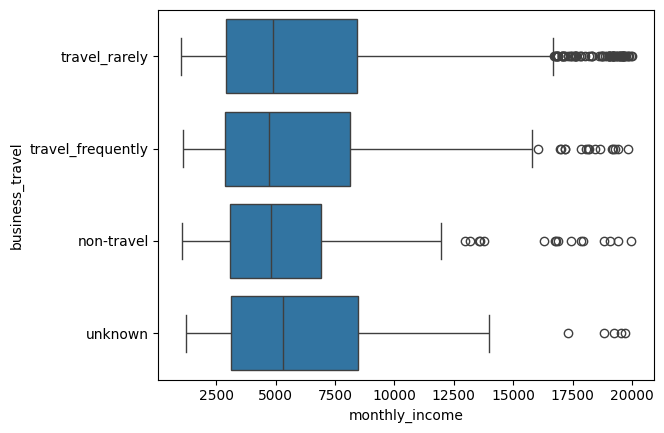

In [225]:
sns.boxplot(data=df_limpio,x="monthly_income",y="business_travel");

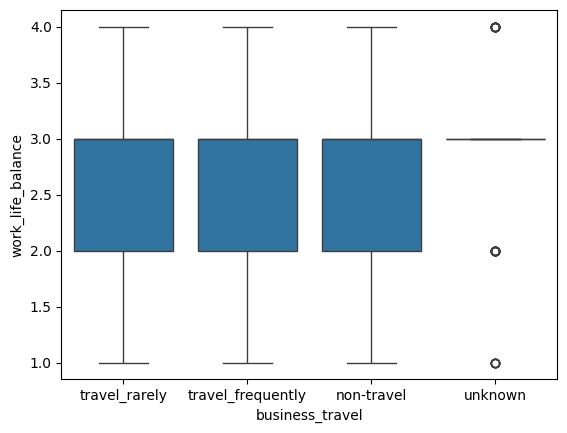

In [226]:
sns.boxplot(data=df_limpio,y="work_life_balance", x="business_travel");

In [227]:
df_limpio.columns

Index(['age', 'attrition', 'business_travel', 'department',
       'distance_from_home', 'education', 'education_field', 'employee_number',
       'environment_satisfaction', 'gender', 'job_involvement', 'job_level',
       'job_role', 'job_satisfaction', 'marital_status', 'monthly_income',
       'num_companies_worked', 'over_time', 'percent_salary_hike',
       'performance_rating', 'relationship_satisfaction', 'stock_option_level',
       'total_working_years', 'training_times_last_year', 'work_life_balance',
       'years_at_company', 'years_in_current_role',
       'years_since_last_promotion', 'years_with_curr_manager', 'media_year',
       'mediana_year'],
      dtype='str')

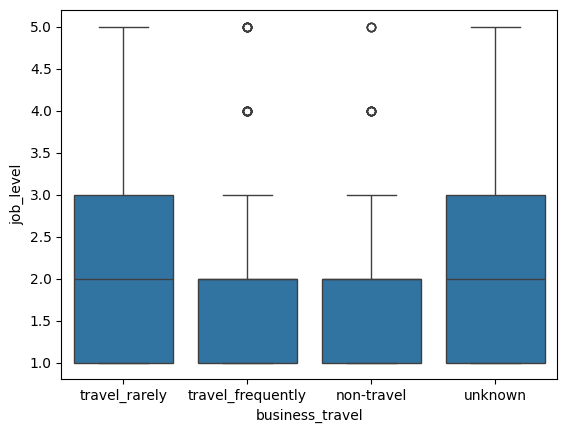

In [228]:
sns.boxplot(data=df_limpio,y="job_level", x="business_travel");

<Axes: xlabel='business_travel', ylabel='count'>

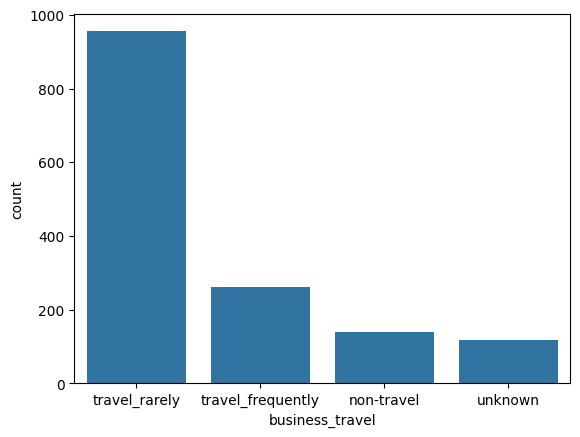

In [229]:
sns.countplot(data=df_limpio,x="business_travel")

In [230]:
df_limpio["business_travel"]= df_limpio["business_travel"].str.replace("unknown","non-travel")
df_limpio["business_travel"].value_counts()

business_travel
travel_rarely        955
travel_frequently    263
non-travel           256
Name: count, dtype: int64

In [231]:
df_limpio["business_travel"].unique()

<StringArray>
['travel_rarely', 'travel_frequently', 'non-travel']
Length: 3, dtype: str

In [232]:
round(df_limpio.isnull().sum()/df_limpio.shape[0]*100, 2).sort_values(ascending = False).head(10)

years_with_curr_manager     10.04
training_times_last_year     5.97
age                          4.95
education_field              3.93
over_time                    2.99
job_satisfaction             1.97
department                   1.97
monthly_income               0.95
employee_number              0.00
gender                       0.00
dtype: float64

In [233]:
df_limpio.head()

,age,attrition,business_travel,department,distance_from_home,education,education_field,employee_number,environment_satisfaction,gender,job_involvement,job_level,job_role,job_satisfaction,marital_status,monthly_income,num_companies_worked,over_time,percent_salary_hike,performance_rating,relationship_satisfaction,stock_option_level,total_working_years,training_times_last_year,work_life_balance,years_at_company,years_in_current_role,years_since_last_promotion,years_with_curr_manager,media_year,mediana_year
0,41.0,yes,travel_rarely,sales,1,2,life sciences,1,2,female,3,2,sales executive,4.0,single,5993.0,8,yes,11,3,1,0,8,0.0,1,6,4,0,5.0,5.0,5.0
1,49.0,no,travel_frequently,research & development,8,1,life sciences,2,3,male,2,2,research scientist,2.0,married,5130.0,1,no,23,4,4,1,10,3.0,3,10,7,1,7.0,7.0,7.0
2,37.0,yes,travel_rarely,research & development,2,2,other,4,4,male,2,1,laboratory technician,3.0,single,2090.0,6,yes,15,3,2,0,7,3.0,3,0,0,0,0.0,0.0,0.0
3,33.0,no,travel_frequently,research & development,3,4,life sciences,5,4,female,3,1,research scientist,3.0,married,2909.0,1,yes,11,3,3,0,8,3.0,3,8,7,3,0.0,0.0,0.0
4,27.0,no,travel_rarely,research & development,2,1,medical,7,1,male,3,1,laboratory technician,2.0,married,3468.0,9,no,12,3,4,1,6,3.0,3,2,2,2,2.0,2.0,2.0


In [234]:
df_limpio.drop(columns=["years_with_curr_manager", "media_year"], inplace=True)

In [235]:
df_limpio.sample()

,age,attrition,business_travel,department,distance_from_home,education,education_field,employee_number,environment_satisfaction,gender,job_involvement,job_level,job_role,job_satisfaction,marital_status,monthly_income,num_companies_worked,over_time,percent_salary_hike,performance_rating,relationship_satisfaction,stock_option_level,total_working_years,training_times_last_year,work_life_balance,years_at_company,years_in_current_role,years_since_last_promotion,mediana_year
272,28.0,no,travel_rarely,research & development,9,3,medical,377,4,male,3,1,research scientist,4.0,married,2070.0,1,no,23,4,4,1,5,3.0,2,5,2,0,4.0


In [236]:
df_limpio.rename(columns= {"mediana_year": "years_with_curr_manager"}, inplace=True)

In [237]:
df_limpio.sample()

,age,attrition,business_travel,department,distance_from_home,education,education_field,employee_number,environment_satisfaction,gender,job_involvement,job_level,job_role,job_satisfaction,marital_status,monthly_income,num_companies_worked,over_time,percent_salary_hike,performance_rating,relationship_satisfaction,stock_option_level,total_working_years,training_times_last_year,work_life_balance,years_at_company,years_in_current_role,years_since_last_promotion,years_with_curr_manager
927,36.0,no,travel_rarely,research & development,2,4,life sciences,1294,3,female,3,2,manufacturing director,2.0,single,5410.0,9,yes,11,3,4,0,18,2.0,3,16,14,5,12.0


In [238]:
df_limpio["education_field"].describe()

count              1416
unique                6
top       life sciences
freq                582
Name: education_field, dtype: object

In [239]:
df_limpio["education_field"].unique()

<StringArray>
[   'life sciences',            'other',          'medical',
                nan,        'marketing', 'technical degree',
  'human resources']
Length: 7, dtype: str

In [240]:
round(df_limpio["education_field"].value_counts(dropna=False)/(df_limpio.shape[0])*100,2).reset_index()

,education_field,count
0,life sciences,39.48
1,medical,30.46
2,marketing,10.31
3,technical degree,8.82
4,other,5.36
5,NaN,3.93
6,human resources,1.63


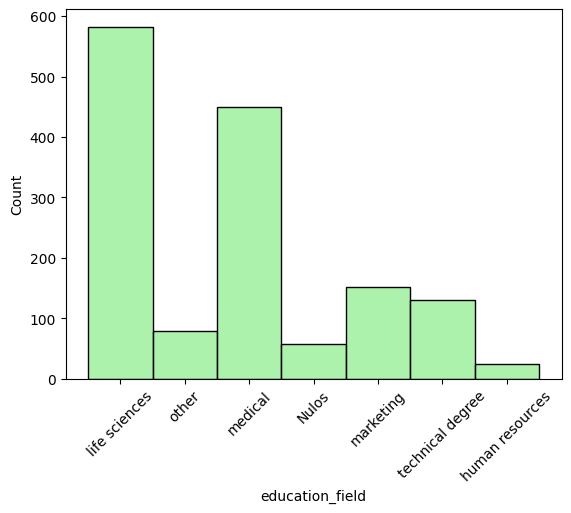

In [241]:
sns.histplot(
    data=df_limpio.assign(
        education_field=df_limpio["education_field"].fillna("Nulos")
    ),
    x="education_field",
    color="lightgreen"
)

plt.xticks(rotation=45)
plt.show()

<Axes: xlabel='education', ylabel='education_field'>

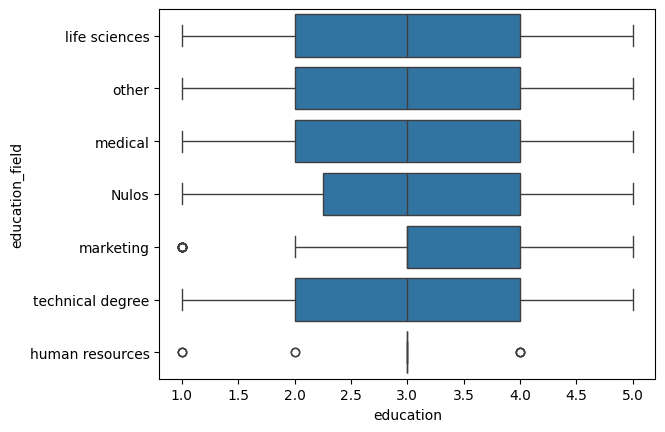

In [242]:
sns.boxplot(data=df_limpio.assign(
        education_field=df_limpio["education_field"].fillna("Nulos")), x= "education", y="education_field")

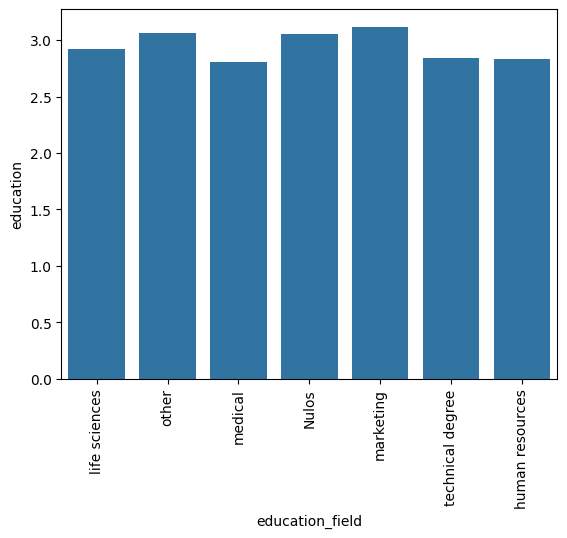

In [243]:
sns.barplot(data=df_limpio.assign(
        education_field=df_limpio["education_field"].fillna("Nulos")),errorbar=None, x= "education_field", y= "education")
plt.xticks(rotation= 90);

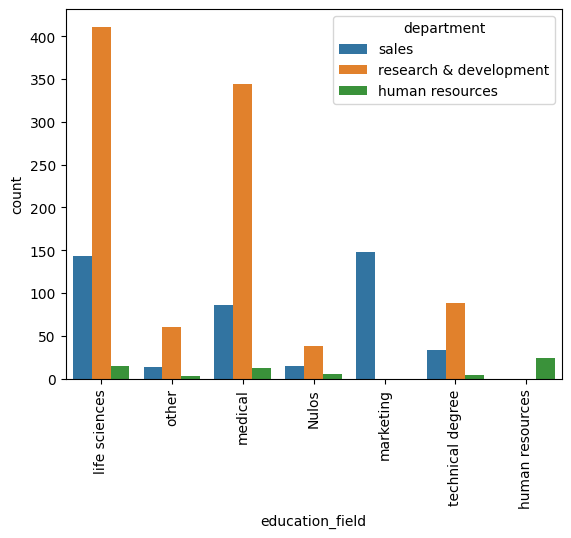

In [244]:
sns.countplot(data=df_limpio.assign(
        education_field=df_limpio["education_field"].fillna("Nulos")), x= "education_field", hue= "department")
plt.xticks(rotation= 90);

In [245]:
df_limpio["education_field"]= df_limpio["education_field"].fillna("other")
df_limpio["education_field"].value_counts(dropna=False)

education_field
life sciences       582
medical             449
marketing           152
other               137
technical degree    130
human resources      24
Name: count, dtype: int64

In [246]:
round(df_limpio.isna().sum().sort_values(ascending=False)/df_limpio.shape[0]*100).head(8), 2

(training_times_last_year    6.0
 age                         5.0
 over_time                   3.0
 department                  2.0
 job_satisfaction            2.0
 monthly_income              1.0
 education_field             0.0
 employee_number             0.0
 dtype: float64,
 2)

In [247]:
df_limpio["training_times_last_year"].value_counts(dropna=False)

training_times_last_year
2.0    520
3.0    456
4.0    118
5.0    111
NaN     88
1.0     65
6.0     63
0.0     53
Name: count, dtype: int64

In [248]:
#Vamos a rellenar los nulos de la columna training_times_last_year por los valores 0.0
# 
df_limpio["training_times_last_year"]= df_limpio["training_times_last_year"].fillna(0.0)
df_limpio["training_times_last_year"].value_counts(dropna=False)

training_times_last_year
2.0    520
3.0    456
0.0    141
4.0    118
5.0    111
1.0     65
6.0     63
Name: count, dtype: int64

In [249]:
df_limpio["age"].value_counts(dropna=False)

age
35.0    73
NaN     73
34.0    72
36.0    68
29.0    65
31.0    63
32.0    59
33.0    57
30.0    57
40.0    56
38.0    54
37.0    50
27.0    48
28.0    46
42.0    41
39.0    41
45.0    41
41.0    39
26.0    36
44.0    32
46.0    32
43.0    30
50.0    27
24.0    24
47.0    24
25.0    23
49.0    22
55.0    21
53.0    19
48.0    18
51.0    18
52.0    17
22.0    16
54.0    16
56.0    14
23.0    13
58.0    13
21.0    11
20.0    11
59.0     9
19.0     8
18.0     8
60.0     5
57.0     4
Name: count, dtype: int64

In [250]:
#Aqui renombramos los nulos de edad por "99"df_limpio

#df_limpio["age"]= df_limpio["age"].fillna(99)

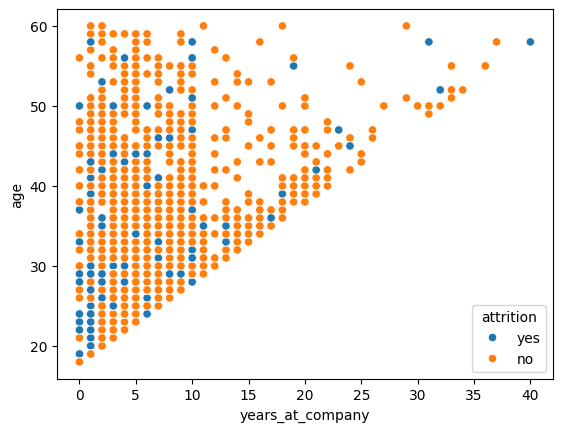

In [251]:
sns.scatterplot(data=df_limpio,y="age",x="years_at_company", hue="attrition");

<Axes: xlabel='years_at_company', ylabel='count'>

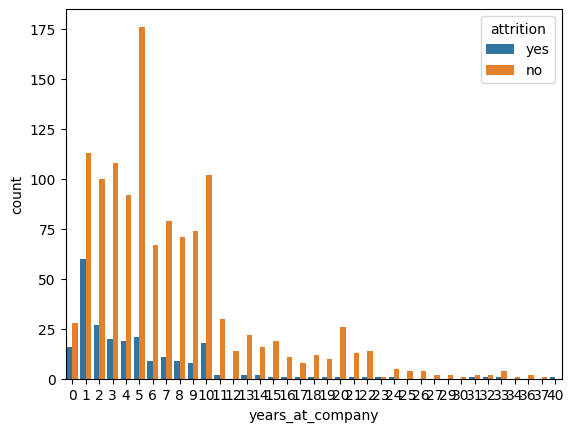

In [252]:
sns.countplot(data=df_limpio,hue="attrition",x="years_at_company")

In [253]:
df_limpio.head(2)

,age,attrition,business_travel,department,distance_from_home,education,education_field,employee_number,environment_satisfaction,gender,job_involvement,job_level,job_role,job_satisfaction,marital_status,monthly_income,num_companies_worked,over_time,percent_salary_hike,performance_rating,relationship_satisfaction,stock_option_level,total_working_years,training_times_last_year,work_life_balance,years_at_company,years_in_current_role,years_since_last_promotion,years_with_curr_manager
0,41.0,yes,travel_rarely,sales,1,2,life sciences,1,2,female,3,2,sales executive,4.0,single,5993.0,8,yes,11,3,1,0,8,0.0,1,6,4,0,5.0
1,49.0,no,travel_frequently,research & development,8,1,life sciences,2,3,male,2,2,research scientist,2.0,married,5130.0,1,no,23,4,4,1,10,3.0,3,10,7,1,7.0


In [254]:
imputer = KNNImputer(n_neighbors=5)  # Imputar utilizando 5 vecinos más cercanos
df_limpio["age_knn"] = imputer.fit_transform(df_limpio[["age", "monthly_income", "years_at_company"]])[:,0]

In [255]:
df_limpio.sample()

,age,attrition,business_travel,department,distance_from_home,education,education_field,employee_number,environment_satisfaction,gender,job_involvement,job_level,job_role,job_satisfaction,marital_status,monthly_income,num_companies_worked,over_time,percent_salary_hike,performance_rating,relationship_satisfaction,stock_option_level,total_working_years,training_times_last_year,work_life_balance,years_at_company,years_in_current_role,years_since_last_promotion,years_with_curr_manager,age_knn
776,20.0,yes,travel_frequently,sales,9,3,marketing,1077,4,female,3,1,sales representative,4.0,single,2323.0,1,yes,14,3,2,0,2,3.0,3,2,2,0,3.0,20.0


In [256]:
df_limpio[["age", "age_knn"]].describe(include=np.number).T

,count,mean,std,min,25%,50%,75%,max
age,1401.0,36.944325,9.105009,18.0,30.0,36.0,43.0,60.0
age_knn,1474.0,36.960380,8.897201,18.0,31.0,36.0,42.0,60.0


In [257]:
df_limpio.drop(columns="age", inplace=True)

In [258]:
df_limpio.rename(columns= {"age_knn": "age"}, inplace=True)

In [259]:
df_limpio.sample()

,attrition,business_travel,department,distance_from_home,education,education_field,employee_number,environment_satisfaction,gender,job_involvement,job_level,job_role,job_satisfaction,marital_status,monthly_income,num_companies_worked,over_time,percent_salary_hike,performance_rating,relationship_satisfaction,stock_option_level,total_working_years,training_times_last_year,work_life_balance,years_at_company,years_in_current_role,years_since_last_promotion,years_with_curr_manager,age
361,no,travel_rarely,research & development,10,4,life sciences,483,4,female,4,1,laboratory technician,3.0,unknown,2213.0,3,NaN,13,3,3,1,10,3.0,3,7,7,1,7.0,40.0


In [260]:
df_limpio["over_time"] = df_limpio["over_time"].fillna("no")

In [261]:
df_limpio.isna().sum().sort_values(ascending=False).head(5)

department            29
job_satisfaction      29
monthly_income        14
distance_from_home     0
attrition              0
dtype: int64

In [262]:
round(df_limpio.isnull().sum()/df_limpio.shape[0]*100, 2).sort_values(ascending = False).head(5)

department            1.97
job_satisfaction      1.97
monthly_income        0.95
distance_from_home    0.00
attrition             0.00
dtype: float64

<Axes: xlabel='department', ylabel='job_role'>

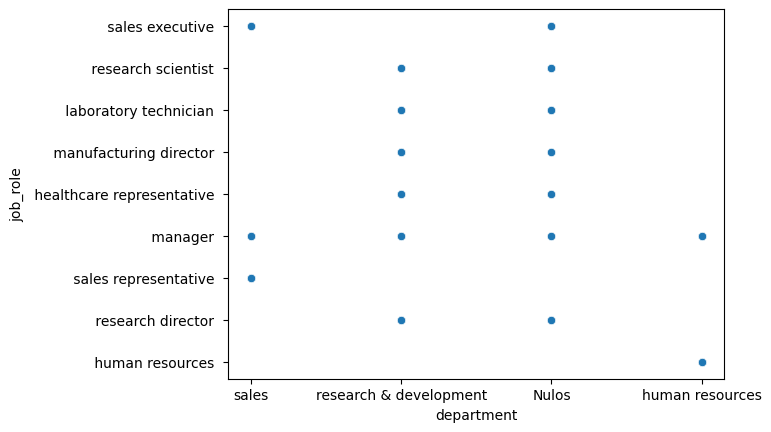

In [263]:
sns.scatterplot(data=df_limpio.assign(
        department=df_limpio["department"].fillna("Nulos")
    ), x="department", y="job_role")

In [264]:
df_limpio["department"] = df_limpio["department"].fillna("unknown")

In [265]:
df_limpio.head(1)

,attrition,business_travel,department,distance_from_home,education,education_field,employee_number,environment_satisfaction,gender,job_involvement,job_level,job_role,job_satisfaction,marital_status,monthly_income,num_companies_worked,over_time,percent_salary_hike,performance_rating,relationship_satisfaction,stock_option_level,total_working_years,training_times_last_year,work_life_balance,years_at_company,years_in_current_role,years_since_last_promotion,years_with_curr_manager,age
0,yes,travel_rarely,sales,1,2,life sciences,1,2,female,3,2,sales executive,4.0,single,5993.0,8,yes,11,3,1,0,8,0.0,1,6,4,0,5.0,41.0


In [266]:
imputer = KNNImputer(n_neighbors=5)  # Imputar utilizando 5 vecinos más cercanos
df_limpio["satisfaction_knn"] = imputer.fit_transform(df_limpio[["job_satisfaction","environment_satisfaction", "relationship_satisfaction"]])[:,0]

In [267]:
df_limpio.sample()

,attrition,business_travel,department,distance_from_home,education,education_field,employee_number,environment_satisfaction,gender,job_involvement,job_level,job_role,job_satisfaction,marital_status,monthly_income,num_companies_worked,over_time,percent_salary_hike,performance_rating,relationship_satisfaction,stock_option_level,total_working_years,training_times_last_year,work_life_balance,years_at_company,years_in_current_role,years_since_last_promotion,years_with_curr_manager,age,satisfaction_knn
252,no,travel_rarely,research & development,15,3,life sciences,346,3,male,3,1,research scientist,4.0,single,2340.0,1,no,19,3,1,0,6,1.0,3,6,5,1,5.0,29.0,4.0


In [268]:
df_limpio[["job_satisfaction", "satisfaction_knn"]].describe().T

,count,mean,std,min,25%,50%,75%,max
job_satisfaction,1445.0,2.728720,1.106409,1.0,2.0,3.0,4.0,4.0
satisfaction_knn,1474.0,2.730393,1.096392,1.0,2.0,3.0,4.0,4.0


In [269]:
df_limpio.drop(columns="job_satisfaction", inplace=True)

In [270]:
df_limpio.rename(columns={"satisfaction_knn": "job_satisfaction"}, inplace=True)

In [271]:
df_limpio.head()

,attrition,business_travel,department,distance_from_home,education,education_field,employee_number,environment_satisfaction,gender,job_involvement,job_level,job_role,marital_status,monthly_income,num_companies_worked,over_time,percent_salary_hike,performance_rating,relationship_satisfaction,stock_option_level,total_working_years,training_times_last_year,work_life_balance,years_at_company,years_in_current_role,years_since_last_promotion,years_with_curr_manager,age,job_satisfaction
0,yes,travel_rarely,sales,1,2,life sciences,1,2,female,3,2,sales executive,single,5993.0,8,yes,11,3,1,0,8,0.0,1,6,4,0,5.0,41.0,4.0
1,no,travel_frequently,research & development,8,1,life sciences,2,3,male,2,2,research scientist,married,5130.0,1,no,23,4,4,1,10,3.0,3,10,7,1,7.0,49.0,2.0
2,yes,travel_rarely,research & development,2,2,other,4,4,male,2,1,laboratory technician,single,2090.0,6,yes,15,3,2,0,7,3.0,3,0,0,0,0.0,37.0,3.0
3,no,travel_frequently,research & development,3,4,life sciences,5,4,female,3,1,research scientist,married,2909.0,1,yes,11,3,3,0,8,3.0,3,8,7,3,0.0,33.0,3.0
4,no,travel_rarely,research & development,2,1,medical,7,1,male,3,1,laboratory technician,married,3468.0,9,no,12,3,4,1,6,3.0,3,2,2,2,2.0,27.0,2.0


In [272]:
df_limpio.isna().sum().sort_values(ascending=False)

monthly_income                14
business_travel                0
department                     0
distance_from_home             0
attrition                      0
education_field                0
employee_number                0
environment_satisfaction       0
gender                         0
job_involvement                0
job_level                      0
job_role                       0
education                      0
marital_status                 0
num_companies_worked           0
over_time                      0
percent_salary_hike            0
performance_rating             0
relationship_satisfaction      0
stock_option_level             0
total_working_years            0
training_times_last_year       0
work_life_balance              0
years_at_company               0
years_in_current_role          0
years_since_last_promotion     0
years_with_curr_manager        0
age                            0
job_satisfaction               0
dtype: int64

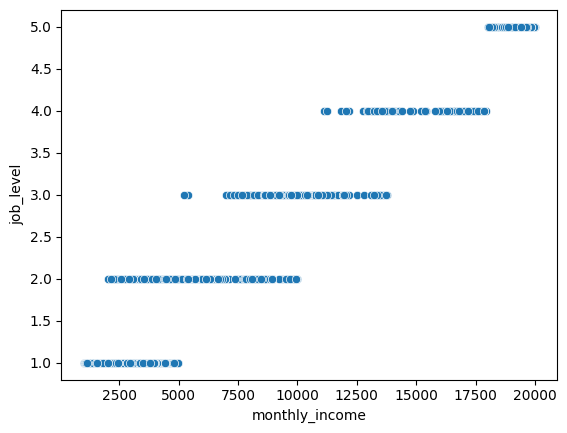

In [273]:
sns.scatterplot(data=df_limpio, x="monthly_income", y="job_level");

In [274]:
imputer = KNNImputer(n_neighbors=5)  # Imputar utilizando 5 vecinos más cercanos
df_limpio["monthly_knn"] = imputer.fit_transform(df_limpio[["monthly_income","job_level", "education"]])[:,0]

In [275]:
df_limpio[["monthly_knn", "monthly_income"]].describe().T

,count,mean,std,min,25%,50%,75%,max
monthly_knn,1474.0,6500.079376,4702.432869,1009.0,2909.5,4936.0,8379.0,19999.0
monthly_income,1460.0,6497.448630,4706.059294,1009.0,2909.0,4907.0,8377.0,19999.0


In [276]:
df_limpio.drop(columns="monthly_income", inplace=True)

In [277]:
df_limpio.rename(columns={"monthly_knn": "monthly_income"}, inplace=True)

In [278]:
df_limpio.isna().sum()

attrition                     0
business_travel               0
department                    0
distance_from_home            0
education                     0
education_field               0
employee_number               0
environment_satisfaction      0
gender                        0
job_involvement               0
job_level                     0
job_role                      0
marital_status                0
num_companies_worked          0
over_time                     0
percent_salary_hike           0
performance_rating            0
relationship_satisfaction     0
stock_option_level            0
total_working_years           0
training_times_last_year      0
work_life_balance             0
years_at_company              0
years_in_current_role         0
years_since_last_promotion    0
years_with_curr_manager       0
age                           0
job_satisfaction              0
monthly_income                0
dtype: int64

In [279]:
df_limpio.info()

<class 'pandas.DataFrame'>
RangeIndex: 1474 entries, 0 to 1473
Data columns (total 29 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   attrition                   1474 non-null   str    
 1   business_travel             1474 non-null   str    
 2   department                  1474 non-null   str    
 3   distance_from_home          1474 non-null   int64  
 4   education                   1474 non-null   int64  
 5   education_field             1474 non-null   str    
 6   employee_number             1474 non-null   int64  
 7   environment_satisfaction    1474 non-null   int64  
 8   gender                      1474 non-null   str    
 9   job_involvement             1474 non-null   int64  
 10  job_level                   1474 non-null   int64  
 11  job_role                    1474 non-null   str    
 12  marital_status              1474 non-null   str    
 13  num_companies_worked        1474 non-null   

In [280]:
df_limpio.head()

,attrition,business_travel,department,distance_from_home,education,education_field,employee_number,environment_satisfaction,gender,job_involvement,job_level,job_role,marital_status,num_companies_worked,over_time,percent_salary_hike,performance_rating,relationship_satisfaction,stock_option_level,total_working_years,training_times_last_year,work_life_balance,years_at_company,years_in_current_role,years_since_last_promotion,years_with_curr_manager,age,job_satisfaction,monthly_income
0,yes,travel_rarely,sales,1,2,life sciences,1,2,female,3,2,sales executive,single,8,yes,11,3,1,0,8,0.0,1,6,4,0,5.0,41.0,4.0,5993.0
1,no,travel_frequently,research & development,8,1,life sciences,2,3,male,2,2,research scientist,married,1,no,23,4,4,1,10,3.0,3,10,7,1,7.0,49.0,2.0,5130.0
2,yes,travel_rarely,research & development,2,2,other,4,4,male,2,1,laboratory technician,single,6,yes,15,3,2,0,7,3.0,3,0,0,0,0.0,37.0,3.0,2090.0
3,no,travel_frequently,research & development,3,4,life sciences,5,4,female,3,1,research scientist,married,1,yes,11,3,3,0,8,3.0,3,8,7,3,0.0,33.0,3.0,2909.0
4,no,travel_rarely,research & development,2,1,medical,7,1,male,3,1,laboratory technician,married,9,no,12,3,4,1,6,3.0,3,2,2,2,2.0,27.0,2.0,3468.0


In [281]:
cambiar_int = ["training_times_last_year", "age",  "job_satisfaction"]

In [282]:
for col in cambiar_int:
    df_limpio[col] = df_limpio[col].astype(int)

In [283]:
df_limpio.info()

<class 'pandas.DataFrame'>
RangeIndex: 1474 entries, 0 to 1473
Data columns (total 29 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   attrition                   1474 non-null   str    
 1   business_travel             1474 non-null   str    
 2   department                  1474 non-null   str    
 3   distance_from_home          1474 non-null   int64  
 4   education                   1474 non-null   int64  
 5   education_field             1474 non-null   str    
 6   employee_number             1474 non-null   int64  
 7   environment_satisfaction    1474 non-null   int64  
 8   gender                      1474 non-null   str    
 9   job_involvement             1474 non-null   int64  
 10  job_level                   1474 non-null   int64  
 11  job_role                    1474 non-null   str    
 12  marital_status              1474 non-null   str    
 13  num_companies_worked        1474 non-null   

In [284]:
df_limpio.to_csv("files/hr_final.csv")